<a href="https://colab.research.google.com/github/bao2001/group4-gdp/blob/main/notebooks/group4_gdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
from pandas_datareader import data as pdr

start = "1990-01-01"
end = "2025-12-31"

# FRED
gdp = pdr.DataReader("GDPC1", "fred", start, end)
unrate = pdr.DataReader("UNRATE", "fred", start, end)
pcepi = pdr.DataReader("PCEPI", "fred", start, end)
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start, end)
spread = pdr.DataReader("T10Y2Y", "fred", start, end)

# Yahoo
sp500 = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False)
vix = yf.download("^VIX", start=start, end=end, auto_adjust=True, progress=False)

# Handle possible multi-index columns from yfinance
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)
if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

sp500 = sp500[["Close"]].rename(columns={"Close": "SP500_Close"})
vix = vix[["Close"]].rename(columns={"Close": "VIX_Close"})

# Resample to quarter end
unrate_q = unrate.resample("QE").mean()
pcepi_q = pcepi.resample("QE").mean()
fedfunds_q = fedfunds.resample("QE").mean()
spread_q = spread.resample("QE").mean()
sp500_q = sp500.resample("QE").last()
vix_q = vix.resample("QE").mean()

# Force GDP to same quarter-end index style
gdp_q = gdp.copy()
gdp_q = gdp_q.to_period("Q").to_timestamp(how="end")
gdp_q.index = gdp_q.index.normalize()

# Normalize all other indexes
for df in [unrate_q, pcepi_q, fedfunds_q, spread_q, sp500_q, vix_q]:
    df.index = df.index.normalize()

# Merge
master = pd.concat(
    [gdp_q, unrate_q, pcepi_q, fedfunds_q, spread_q, sp500_q, vix_q],
    axis=1
)

master.columns = [
    "GDPC1",
    "UNRATE",
    "PCEPI",
    "FEDFUNDS",
    "T10Y2Y",
    "SP500_Close",
    "VIX_Close"
]

print("Before dropna:", master.shape)
print(master.isna().sum())

master = master.dropna().copy()

print("After dropna:", master.shape)
print(master.head())
print(master.tail())

Before dropna: (144, 7)
GDPC1          0
UNRATE         0
PCEPI          0
FEDFUNDS       0
T10Y2Y         0
SP500_Close    0
VIX_Close      0
dtype: int64
After dropna: (144, 7)
                GDPC1    UNRATE      PCEPI  FEDFUNDS    T10Y2Y  SP500_Close  \
1990-03-31  10047.386  5.300000  58.799000  8.250000  0.059032   339.940002   
1990-06-30  10083.855  5.333333  59.333000  8.243333  0.103016   358.019989   
1990-09-30  10090.569  5.700000  60.086667  8.160000  0.602540   306.049988   
1990-12-31   9998.704  6.133333  60.881333  7.743333  0.800161   330.220001   
1991-03-31   9951.916  6.600000  61.202000  6.426667  0.987167   375.220001   

            VIX_Close  
1990-03-31  22.174603  
1990-06-30  18.722063  
1990-09-30  25.195556  
1990-12-31  26.113281  
1991-03-31  22.494754  
                GDPC1    UNRATE       PCEPI  FEDFUNDS    T10Y2Y  SP500_Close  \
2024-12-31  23586.542  4.133333  124.703333  4.650000  0.130000  5881.629883   
2025-03-31  23548.210  4.133333  125.75966

In [8]:
print(master.info())
print(master.isna().sum())
print(master.index.min(), master.index.max())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1990-03-31 to 2025-12-31
Freq: QE-DEC
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GDPC1        144 non-null    float64
 1   UNRATE       144 non-null    float64
 2   PCEPI        144 non-null    float64
 3   FEDFUNDS     144 non-null    float64
 4   T10Y2Y       144 non-null    float64
 5   SP500_Close  144 non-null    float64
 6   VIX_Close    144 non-null    float64
dtypes: float64(7)
memory usage: 9.0 KB
None
GDPC1          0
UNRATE         0
PCEPI          0
FEDFUNDS       0
T10Y2Y         0
SP500_Close    0
VIX_Close      0
dtype: int64
1990-03-31 00:00:00 2025-12-31 00:00:00


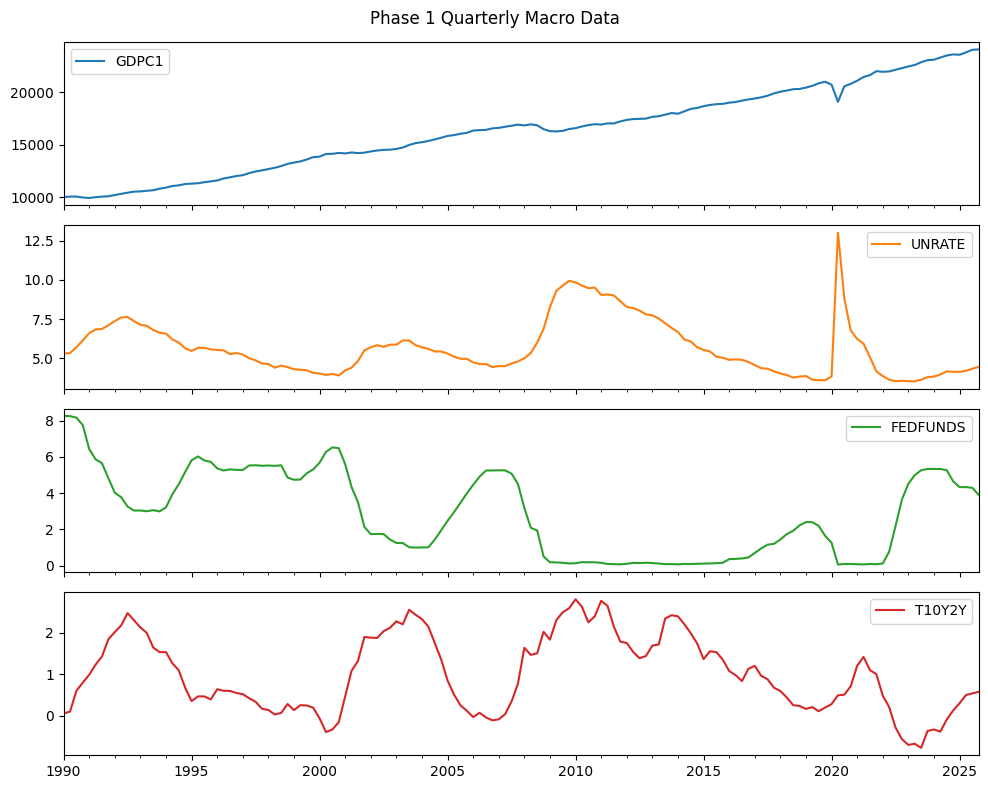

In [10]:
import matplotlib.pyplot as plt

master[["GDPC1", "UNRATE", "FEDFUNDS", "T10Y2Y"]].plot(
    subplots=True, figsize=(10, 8), title="Phase 1 Quarterly Macro Data"
)
plt.tight_layout()
plt.show()

In [11]:
master["log_GDPC1"] = np.log(master["GDPC1"])
master["gdp_growth"] = master["GDPC1"].pct_change()
master["sp500_return"] = master["SP500_Close"].pct_change()
master["vix_change"] = master["VIX_Close"].pct_change()

master.head()

,GDPC1,UNRATE,PCEPI,FEDFUNDS,T10Y2Y,SP500_Close,VIX_Close,log_GDPC1,gdp_growth,sp500_return,vix_change
1990-03-31,10047.386,5.300000,58.799000,8.250000,0.059032,339.940002,22.174603,9.215068,NaN,NaN,NaN
1990-06-30,10083.855,5.333333,59.333000,8.243333,0.103016,358.019989,18.722063,9.218691,0.003630,0.053186,-0.155698
1990-09-30,10090.569,5.700000,60.086667,8.160000,0.602540,306.049988,25.195556,9.219357,0.000666,-0.145159,0.345768
1990-12-31,9998.704,6.133333,60.881333,7.743333,0.800161,330.220001,26.113281,9.210211,-0.009104,0.078974,0.036424
1991-03-31,9951.916,6.600000,61.202000,6.426667,0.987167,375.220001,22.494754,9.205520,-0.004679,0.136273,-0.138570
